# 🛒 Retail Analytics Pipeline
## Evaluación Módulo 9 — Fundamentos de Big Data
**Empresa:** RetailMax | **Tecnología:** Apache Spark + PySpark + MLlib  
**Dataset:** Online Retail II (UCI Machine Learning Repository)  
**Entorno:** Google Colab / Local con PySpark

---

## Índice del Proyecto

| Lección | Contenido |
|---|---|
| **L1** | Fundamentos de Big Data — Contexto y Arquitectura RetailMax |
| **L2** | Configuración de Spark — SparkSession, RDDs iniciales |
| **L3** | RDDs, Transformaciones y Acciones — Linaje y DAG |
| **L4** | DataFrames y Spark SQL — Métricas de Negocio y Parquet |
| **L5** | MLlib — Pipeline de Clasificación y Segmentación |

---

# LECCIÓN 1 — Fundamentos de Big Data
## Informe Conceptual Base: Caso RetailMax

### 1.1 Las 5V de Big Data aplicadas a RetailMax

El ecosistema de Big Data se define por cinco dimensiones críticas que determinan la complejidad y el valor de los datos. A continuación se analiza cada dimensión en el contexto específico de RetailMax:

| Dimensión | Descripción General | Aplicación en RetailMax |
|---|---|---|
| **Volumen** | Cantidad masiva de datos generados | Millones de transacciones diarias, histórico de 2 años (Online Retail II: ~1M registros) |
| **Velocidad** | Rapidez de generación e ingesta | Órdenes en tiempo real, clics de navegación por sesión, eventos de carrito |
| **Variedad** | Diversidad de tipos y formatos | Datos estructurados (CSV transaccional), semi-estructurados (logs), no estructurados (reseñas de texto) |
| **Veracidad** | Calidad y confiabilidad de los datos | Registros con `CustomerID` nulo, cantidades negativas (devoluciones), descripciones inconsistentes |
| **Valor** | Insights accionables extraídos | Segmentación RFM, predicción de churn, recomendaciones personalizadas para marketing |

**Impacto en el proyecto:** Las 5V justifican el uso de Apache Spark como motor de procesamiento distribuido. Un sistema tradicional (pandas, SQL monolítico) no puede escalar ante el volumen de transacciones de RetailMax ni procesar datos en tiempo cuasi-real.

---

### 1.2 Fuentes de Datos de RetailMax

RetailMax opera con tres fuentes principales de datos:

**1. Transacciones de compra (fuente principal — Online Retail II)**  
- Formato: CSV estructurado  
- Columnas clave: `Invoice`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `Price`, `CustomerID`, `Country`  
- Contiene: compras válidas (Invoice sin prefijo 'C') y devoluciones (Invoice con 'C')

**2. Comportamiento de navegación (simulado/derivado)**  
- Derivado de patrones de compra: frecuencia de visitas, diversidad de productos consultados  
- Variable construida: `diversidad_productos` (cantidad de StockCodes únicos por cliente)

**3. Reseñas y calificaciones (simulado)**  
- Para este proyecto se construye una variable proxy: `ticket_promedio` y `frecuencia_compra`  
- Justificación: el dataset Online Retail II no incluye reseñas explícitas; se aplica ingeniería de variables razonable basada en el comportamiento transaccional

---

### 1.3 Arquitectura Propuesta para el Proyecto

```
┌─────────────────────────────────────────────────────────────────┐
│                    ARQUITECTURA RETAILMAX                        │
│                                                                 │
│  [FUENTES DE DATOS]          [PROCESAMIENTO]      [SALIDAS]     │
│                                                                 │
│  Online Retail II CSV  ──►  SparkContext/RDD  ──►  Métricas     │
│  Logs navegación       ──►  SparkSession/DF   ──►  Parquet      │
│  Reseñas (simuladas)   ──►  Spark SQL         ──►  CSV/Viz      │
│                                │                                │
│                         [MLlib Pipeline]                        │
│                         VectorAssembler                         │
│                         StringIndexer                           │
│                         LogisticRegression ──►  Clasificación   │
│                         K-Means            ──►  Segmentos       │
│                                                                 │
│  Optimización: cache() / persist() / Parquet columnar           │
└─────────────────────────────────────────────────────────────────┘
```

**Flujo de datos:**  
`Ingesta CSV` → `RDDs (L2/L3)` → `DataFrames + SQL (L4)` → `Parquet` → `MLlib Pipeline (L5)` → `Insights Marketing`

---

# LECCIÓN 2 — Apache Spark: Introducción y Configuración
## Objetivo: Configurar Spark e iniciar el procesamiento distribuido

En esta lección configuramos el entorno de PySpark, inicializamos `SparkSession` y realizamos la carga inicial del dataset Online Retail II en RDDs, validando la conectividad y explorando acciones básicas.

In [1]:
# ─── INSTALACIÓN (solo necesario en Google Colab) ───────────────────────────
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !apt-get install -q openjdk-11-jdk-headless
    !pip install -q pyspark==3.5.0
    import os
    os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'

print('Entorno listo.')

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  openjdk-11-jre-headless
Suggested packages:
  openjdk-11-demo openjdk-11-source libnss-mdns fonts-dejavu-extra
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  openjdk-11-jdk-headless openjdk-11-jre-headless
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 116 MB of archives.
After this operation, 258 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 openjdk-11-jre-headless amd64 11.0.30+7-1ubuntu1~22.04 [42.6 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 openjdk-11-jdk-headless amd64 11.0.30+7-1ubuntu1~22.04 [73.7 MB]
Fetched 116 MB in 5s (21.2 MB/s)
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118194 files 

In [2]:
# ─── CONFIGURACIÓN DE SPARKSESSION ──────────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf

spark = (
    SparkSession.builder
    .appName('RetailMax_Analytics_Pipeline')
    .master('local[*]')               # Usa todos los cores disponibles
    .config('spark.sql.shuffle.partitions', '8')   # Ajustado para dataset local
    .config('spark.driver.memory', '2g')
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel('ERROR')              # Silencia warnings informativos

print(f'Spark version : {spark.version}')
print(f'App name      : {sc.appName}')
print(f'Master        : {sc.master}')
print(f'Default cores : {sc.defaultParallelism}')

Spark version : 3.5.0
App name      : RetailMax_Analytics_Pipeline
Master        : local[*]
Default cores : 2


In [3]:
# ─── DESCARGA DEL DATASET: Online Retail II (UCI) ────────────────────────────
# El dataset Online Retail II contiene transacciones de un e-commerce del
# Reino Unido entre 2009 y 2011. Aprox. 1 millón de registros en dos hojas.

import os
import urllib.request

DATA_URL  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx'
DATA_FILE = 'online_retail_II.xlsx'
CSV_FILE  = 'online_retail_II.csv'

if not os.path.exists(CSV_FILE):
    print('Descargando dataset...')
    try:
        urllib.request.urlretrieve(DATA_URL, DATA_FILE)
        import pandas as pd
        # Leer ambas hojas y concatenar
        df_09 = pd.read_excel(DATA_FILE, sheet_name='Year 2009-2010', engine='openpyxl')
        df_10 = pd.read_excel(DATA_FILE, sheet_name='Year 2010-2011', engine='openpyxl')
        df_raw = pd.concat([df_09, df_10], ignore_index=True)
        df_raw.to_csv(CSV_FILE, index=False)
        print(f'Dataset guardado: {len(df_raw):,} registros totales.')
    except Exception as e:
        print(f'Error de descarga: {e}')
        print('Generando dataset sintético representativo...')
        _generate_synthetic_dataset(CSV_FILE)
else:
    print(f'Dataset ya existe: {CSV_FILE}')

Descargando dataset...
Dataset guardado: 1,067,371 registros totales.


In [4]:
# ─── DATASET SINTÉTICO (fallback si descarga falla) ──────────────────────────
# Generamos un dataset sintético fiel a la estructura del Online Retail II
# para garantizar reproducibilidad del proyecto en entornos sin internet.

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

def _generate_synthetic_dataset(path, n=50_000, seed=42):
    rng = np.random.default_rng(seed)
    random.seed(seed)

    stock_codes = [f'S{i:04d}' for i in range(1, 201)]
    descriptions = [
        'WHITE HANGING HEART T-LIGHT HOLDER', 'CREAM CUPID HEARTS COAT HANGER',
        'GLASS STAR FROSTED T-LIGHT HOLDER', 'HAND WARMER UNION JACK',
        'RETRO COFFEE MUGS ASSORTED', 'SET OF 6 WOODLAND PAPER CUPS',
        'LUNCH BAG PINK POLKA DOT', 'JUMBO BAG RED RETROSPOT',
        'RED WOOLLY HOTTIE WHITE HEART', 'BLUE SPOT GIFT BAG LARGE',
        'STRAWBERRY CERAMIC TRINKET BOX', 'PAPER CHAIN KIT 50S CHRISTMAS',
        'WOODEN PICTURE FRAME WHITE FINISH', 'SET/6 RED SPOTTY PAPER PLATES',
        'VICTORIAN GLASS HANGING T-LIGHT', 'NATURAL SLATE HEART CHALKBOARD',
        'ENGLISH ROSE HOT WATER BOTTLE', 'ASSORTED COLOUR BIRD ORNAMENT',
        'RABBIT NIGHT LIGHT', 'MINI PAINT SET VINTAGE'
    ] * 10  # repetir para 200 productos

    countries = ['United Kingdom', 'Germany', 'France', 'Netherlands',
                 'Australia', 'Spain', 'Belgium', 'Switzerland', 'Portugal', 'USA']
    country_weights = [0.55, 0.10, 0.08, 0.05, 0.04, 0.04, 0.03, 0.03, 0.03, 0.05]

    customer_ids = list(range(12000, 12500))  # 500 clientes

    start_date = datetime(2009, 12, 1)
    dates = [start_date + timedelta(days=int(rng.integers(0, 730))) for _ in range(n)]

    invoices = [f'{int(rng.integers(489000, 581590))}' for _ in range(n)]
    # ~5% devoluciones
    invoices = [('C' + inv if rng.random() < 0.05 else inv) for inv in invoices]

    idx = rng.integers(0, len(stock_codes), n)
    data = {
        'Invoice'     : invoices,
        'StockCode'   : [stock_codes[i] for i in idx],
        'Description' : [descriptions[i % len(descriptions)] for i in idx],
        'Quantity'    : rng.integers(1, 50, n).tolist(),
        'InvoiceDate' : dates,
        'Price'       : np.round(rng.uniform(0.5, 25.0, n), 2).tolist(),
        'CustomerID'  : [str(random.choice(customer_ids)) if rng.random() > 0.15
                         else None for _ in range(n)],
        'Country'     : rng.choice(countries, n, p=country_weights).tolist()
    }
    pd.DataFrame(data).to_csv(path, index=False)
    print(f'Dataset sintético generado: {n:,} registros en {path}')

import os
CSV_FILE = 'online_retail_II.csv'
if not os.path.exists(CSV_FILE):
    _generate_synthetic_dataset(CSV_FILE)

print('Dataset listo.')

Dataset listo.


In [5]:
# ─── CARGA INICIAL EN RDD ────────────────────────────────────────────────────
# SparkContext.textFile() carga el CSV como RDD de strings (una línea = un elemento)

rdd_raw = sc.textFile(CSV_FILE)

# Separar encabezado para no procesarlo como dato
header  = rdd_raw.first()
rdd_data = rdd_raw.filter(lambda line: line != header)

# ── Acciones básicas de validación ──
total_lines = rdd_data.count()
sample      = rdd_data.take(3)

print(f'Total de registros (sin encabezado): {total_lines:,}')
print(f'\nColumnas: {header}')
print(f'\nPrimeras 3 líneas:')
for i, line in enumerate(sample, 1):
    print(f'  [{i}] {line[:120]}...' if len(line) > 120 else f'  [{i}] {line}')

Total de registros (sin encabezado): 1,067,371

Columnas: Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country

Primeras 3 líneas:
  [1] 489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
  [2] 489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
  [3] 489434,79323W, WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


# LECCIÓN 3 — Elementos Básicos de Spark: RDDs, Transformaciones y Acciones
## Objetivo: Manipular grandes volúmenes de datos con RDDs

En esta lección construimos RDDs tipados a partir del CSV crudo, aplicamos transformaciones lazy (map, filter, flatMap, distinct, sortBy) y ejecutamos acciones que disparan la evaluación real del DAG. Se documenta el linaje de cada RDD.

In [6]:
# ─── PARSING DEL RDD RAW A TUPLAS TIPADAS ────────────────────────────────────
# Estructura del CSV: Invoice, StockCode, Description, Quantity,
#                     InvoiceDate, Price, CustomerID, Country

from datetime import datetime

def parse_line(line):
    """Parsea una línea CSV robustamente. Retorna None si hay error de parseo."""
    try:
        # Manejo básico de CSV: split por coma con cuidado de campos vacíos
        parts = line.split(',')
        if len(parts) < 8:
            return None
        invoice     = parts[0].strip()
        stock_code  = parts[1].strip()
        description = parts[2].strip()
        quantity    = int(float(parts[3].strip()))   if parts[3].strip() else 0
        inv_date    = parts[4].strip()[:10]           # YYYY-MM-DD
        price       = float(parts[5].strip())         if parts[5].strip() else 0.0
        customer_id = parts[6].strip()                if parts[6].strip() else None
        country     = parts[7].strip()
        return (invoice, stock_code, description, quantity, inv_date,
                price, customer_id, country)
    except Exception:
        return None

rdd_parsed = (
    rdd_data
    .map(parse_line)                         # Transformación: parsear cada línea
    .filter(lambda r: r is not None)         # Eliminar líneas con error
)

# Acción de validación
print(f'Registros parseados correctamente: {rdd_parsed.count():,}')

Registros parseados correctamente: 1,051,881


In [7]:
# ─── TRANSFORMACIONES SOBRE EL RDD ───────────────────────────────────────────

# 1. FILTER — Excluir devoluciones (Invoice que empieza con 'C') y
#             registros sin CustomerID o con precio/cantidad inválidos
rdd_compras = rdd_parsed.filter(
    lambda r: (
        not r[0].startswith('C')   # Sin devoluciones
        and r[6] is not None       # Con CustomerID
        and r[3] > 0               # Cantidad positiva
        and r[5] > 0.0             # Precio positivo
    )
)
print(f'Compras válidas (sin devoluciones, con cliente): {rdd_compras.count():,}')

# 2. MAP — Calcular gasto por línea: gasto_linea = Quantity * Price
rdd_con_gasto = rdd_compras.map(
    lambda r: r + (round(r[3] * r[5], 2),)   # Añadir campo gasto_linea (índice 8)
)

# 3. DISTINCT — Países únicos en el dataset
paises_unicos = rdd_compras.map(lambda r: r[7]).distinct().collect()
print(f'Países únicos: {sorted(paises_unicos)}')

# 4. SORTBY — Top 10 líneas con mayor gasto
top10_gasto = rdd_con_gasto.sortBy(lambda r: r[8], ascending=False).take(10)
print(f'\nTop 3 líneas por gasto:')
for r in top10_gasto[:3]:
    print(f'  Invoice={r[0]} | Producto={r[2][:30]} | Qty={r[3]} | Price={r[5]} | Gasto={r[8]}')

# 5. FLATMAP — Extraer palabras de todas las descripciones de productos
rdd_palabras = rdd_compras.flatMap(lambda r: r[2].upper().split())
top_palabras = rdd_palabras.map(lambda w: (w, 1)).reduceByKey(lambda a, b: a + b) \
                           .sortBy(lambda x: x[1], ascending=False).take(10)
print(f'\nTop 10 palabras en descripciones: {top_palabras}')

Compras válidas (sin devoluciones, con cliente): 794,389
Países únicos: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Israel', 'Italy', 'Japan', 'Korea', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Nigeria', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unspecified', 'West Indies']

Top 3 líneas por gasto:
  Invoice=541431 | Producto=MEDIUM CERAMIC TOP STORAGE JAR | Qty=74215 | Price=1.04 | Gasto=77183.6
  Invoice=556444 | Producto=PICNIC BASKET WICKER 60 PIECES | Qty=60 | Price=649.5 | Gasto=38970.0
  Invoice=530715 | Producto=ROTATING SILVER ANGELS T-LIGHT | Qty=9360 | Price=1.69 | Gasto=15818.4

Top 10 palabras en descripciones: [('OF', 70705), ('SET', 69959), ('RED', 69425), ('BAG', 69389), ('HEART', 

In [8]:
# ─── PAIR RDDs — MÉTRICAS AGREGADAS POR CLIENTE ──────────────────────────────
# Un Pair RDD es un RDD de tuplas (K, V) que habilita operaciones clave-valor.

# Pair RDD: (CustomerID, gasto_linea)
rdd_cliente_gasto = rdd_con_gasto.map(lambda r: (r[6], r[8]))

# Gasto total por cliente
rdd_gasto_total = rdd_cliente_gasto.reduceByKey(lambda a, b: a + b)

# Cantidad de transacciones por cliente
rdd_cliente_one    = rdd_con_gasto.map(lambda r: (r[6], 1))
rdd_frecuencia     = rdd_cliente_one.reduceByKey(lambda a, b: a + b)

# ── ACCIONES: estadísticas sobre el gasto total por cliente ──────────────────
gastos_values = rdd_gasto_total.values()    # RDD solo con los valores (gastos)

stats_gasto = gastos_values.stats()         # Acción: devuelve StatCounter
print('=== Estadísticas de Gasto Total por Cliente ===')
print(f'  Clientes únicos : {int(stats_gasto.count()):,}')
print(f'  Gasto mínimo    : ${stats_gasto.min():,.2f}')
print(f'  Gasto máximo    : ${stats_gasto.max():,.2f}')
print(f'  Gasto promedio  : ${stats_gasto.mean():,.2f}')
print(f'  Desv. estándar  : ${stats_gasto.stdev():,.2f}')
print(f'  Gasto total (suma): ${stats_gasto.sum():,.2f}')

=== Estadísticas de Gasto Total por Cliente ===
  Clientes únicos : 5,875
  Gasto mínimo    : $2.90
  Gasto máximo    : $599,076.81
  Gasto promedio  : $2,962.82
  Desv. estándar  : $14,400.61
  Gasto total (suma): $17,406,577.38


In [9]:
# ─── LINAJE DEL RDD Y DOCUMENTACIÓN DEL DAG ──────────────────────────────────
# toDebugString() imprime el plan de linaje completo (dependencias entre RDDs)

print('=== LINAJE del RDD rdd_gasto_total ===')
print(rdd_gasto_total.toDebugString().decode('utf-8'))

print('\n--- Explicación del DAG ---')
print("""
El DAG (Directed Acyclic Graph) de rdd_gasto_total se construye así:

  [1] sc.textFile(CSV)          → RDD[String]       (lectura paralela por bloques)
       ↓ filter(header)
  [2] rdd_data                  → RDD[String]       (narrow dependency)
       ↓ map(parse_line)
  [3] rdd_parsed                → RDD[Tuple]        (narrow dependency)
       ↓ filter(compras válidas)
  [4] rdd_compras               → RDD[Tuple]        (narrow dependency)
       ↓ map(añadir gasto_linea)
  [5] rdd_con_gasto             → RDD[Tuple]        (narrow dependency)
       ↓ map(customerID, gasto)
  [6] rdd_cliente_gasto         → PairRDD[(K,V)]    (narrow dependency)
       ↓ reduceByKey(sum)
  [7] rdd_gasto_total           → PairRDD[(K,V)]    (WIDE dependency — shuffle)

Nota: reduceByKey genera una dependencia wide (shuffle) porque los datos
deben reagruparse entre particiones para sumar los valores por clave.
Las transformaciones anteriores son narrow (no requieren shuffle).
Spark ejecuta todo esto de forma LAZY: solo se computa al llamar .stats().
""")

=== LINAJE del RDD rdd_gasto_total ===
(3) PythonRDD[39] at RDD at PythonRDD.scala:53 []
 |  MapPartitionsRDD[33] at mapPartitions at PythonRDD.scala:160 []
 |  ShuffledRDD[32] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(3) PairwiseRDD[31] at reduceByKey at /tmp/ipykernel_21583/2500314354.py:8 []
    |  PythonRDD[30] at reduceByKey at /tmp/ipykernel_21583/2500314354.py:8 []
    |  online_retail_II.csv MapPartitionsRDD[1] at textFile at NativeMethodAccessorImpl.java:0 []
    |  online_retail_II.csv HadoopRDD[0] at textFile at NativeMethodAccessorImpl.java:0 []

--- Explicación del DAG ---

El DAG (Directed Acyclic Graph) de rdd_gasto_total se construye así:

  [1] sc.textFile(CSV)          → RDD[String]       (lectura paralela por bloques)
       ↓ filter(header)
  [2] rdd_data                  → RDD[String]       (narrow dependency)
       ↓ map(parse_line)
  [3] rdd_parsed                → RDD[Tuple]        (narrow dependency)
       ↓ filter(compras válidas)
  [4] rdd_co

In [10]:
# ─── OPTIMIZACIÓN: cache() y persist() ───────────────────────────────────────
# rdd_compras se reutiliza en múltiples transformaciones → conviene cachearlo
# para evitar recomputar desde el CSV en cada acción.

from pyspark import StorageLevel

# cache() = persist(MEMORY_ONLY)
rdd_compras.cache()

# Para RDDs grandes que no caben en memoria usaríamos:
# rdd_compras.persist(StorageLevel.MEMORY_AND_DISK)

# Primera acción — materializa y guarda en memoria
n1 = rdd_compras.count()

# Segunda acción — lee desde caché (mucho más rápido)
n2 = rdd_compras.filter(lambda r: r[7] == 'United Kingdom').count()

print(f'Total compras válidas          : {n1:,}')
print(f'Compras desde Reino Unido      : {n2:,} ({n2/n1*100:.1f}%)')
print(f'rdd_compras cacheado           : {rdd_compras.is_cached}')

Total compras válidas          : 794,389
Compras desde Reino Unido      : 715,095 (90.0%)
rdd_compras cacheado           : True


# LECCIÓN 4 — Procesamiento de Datos Estructurados: Spark SQL y DataFrames
## Objetivo: Analizar datos estructurados con DataFrames y Spark SQL, generar métricas de negocio

Transformamos los RDDs tipados a DataFrames con esquema explícito, registramos vistas SQL para consultas analíticas y guardamos los resultados en formato Parquet para su uso en la Lección 5.

In [11]:
# ─── RDD → DATAFRAME CON ESQUEMA EXPLÍCITO ───────────────────────────────────
from pyspark.sql.types import (StructType, StructField, StringType,
                                IntegerType, DoubleType, DateType)
from pyspark.sql import Row

schema_compras = StructType([
    StructField('invoice',      StringType(),  nullable=False),
    StructField('stock_code',   StringType(),  nullable=False),
    StructField('description',  StringType(),  nullable=True),
    StructField('quantity',     IntegerType(), nullable=False),
    StructField('invoice_date', StringType(),  nullable=False),  # string → cast luego
    StructField('price',        DoubleType(),  nullable=False),
    StructField('customer_id',  StringType(),  nullable=True),
    StructField('country',      StringType(),  nullable=True),
    StructField('gasto_linea',  DoubleType(),  nullable=False),
])

# Convertir RDD de tuplas a Row objects
rdd_rows = rdd_con_gasto.map(lambda r: Row(
    invoice=r[0], stock_code=r[1], description=r[2], quantity=r[3],
    invoice_date=r[4], price=r[5], customer_id=r[6], country=r[7],
    gasto_linea=r[8]
))

df_transacciones = spark.createDataFrame(rdd_rows, schema=schema_compras)

# Cast de fecha y añadir columna de mes/año
from pyspark.sql import functions as F

df_transacciones = (
    df_transacciones
    .withColumn('invoice_date', F.to_date('invoice_date'))
    .withColumn('anio_mes', F.date_format('invoice_date', 'yyyy-MM'))
    .withColumn('anio',     F.year('invoice_date'))
)

df_transacciones.cache()   # Cachear: se usará múltiples veces

print(f'Schema del DataFrame:')
df_transacciones.printSchema()
print(f'Total registros: {df_transacciones.count():,}')
df_transacciones.show(5, truncate=40)

Schema del DataFrame:
root
 |-- invoice: string (nullable = false)
 |-- stock_code: string (nullable = false)
 |-- description: string (nullable = true)
 |-- quantity: integer (nullable = false)
 |-- invoice_date: date (nullable = true)
 |-- price: double (nullable = false)
 |-- customer_id: string (nullable = true)
 |-- country: string (nullable = true)
 |-- gasto_linea: double (nullable = false)
 |-- anio_mes: string (nullable = true)
 |-- anio: integer (nullable = true)

Total registros: 794,389
+-------+----------+-----------------------------------+--------+------------+-----+-----------+--------------+-----------+--------+----+
|invoice|stock_code|                        description|quantity|invoice_date|price|customer_id|       country|gasto_linea|anio_mes|anio|
+-------+----------+-----------------------------------+--------+------------+-----+-----------+--------------+-----------+--------+----+
| 489434|     85048|15CM CHRISTMAS GLASS BALL 20 LIGHTS|      12|  2009-12-01| 6.9

In [12]:
# ─── SPARK SQL: REGISTRO DE VISTA Y CONSULTAS DE NEGOCIO ─────────────────────

df_transacciones.createOrReplaceTempView('transacciones')

# ── Consulta 1: Ventas totales por país (top 10) ──────────────────────────────
print('=== VENTAS TOTALES POR PAÍS (Top 10) ===')
df_ventas_pais = spark.sql("""
    SELECT
        country,
        COUNT(DISTINCT invoice)  AS num_ordenes,
        SUM(quantity)            AS unidades_vendidas,
        ROUND(SUM(gasto_linea), 2) AS ingresos_totales
    FROM transacciones
    GROUP BY country
    ORDER BY ingresos_totales DESC
    LIMIT 10
""")
df_ventas_pais.show(truncate=False)

# ── Consulta 2: Top 15 productos por ingreso ──────────────────────────────────
print('=== TOP 15 PRODUCTOS POR INGRESO ===')
df_top_productos = spark.sql("""
    SELECT
        stock_code,
        FIRST(description)       AS descripcion,
        SUM(quantity)            AS unidades_totales,
        ROUND(SUM(gasto_linea), 2) AS ingresos_totales,
        ROUND(AVG(price), 2)     AS precio_promedio
    FROM transacciones
    GROUP BY stock_code
    ORDER BY ingresos_totales DESC
    LIMIT 15
""")
df_top_productos.show(truncate=50)

=== VENTAS TOTALES POR PAÍS (Top 10) ===
+--------------+-----------+-----------------+----------------+
|country       |num_ordenes|unidades_vendidas|ingresos_totales|
+--------------+-----------+-----------------+----------------+
|United Kingdom|33504      |8500836          |1.441844273E7   |
|EIRE          |567        |318208           |616482.67       |
|Netherlands   |228        |376017           |544040.83       |
|Germany       |788        |224896           |426494.09       |
|France        |614        |272300           |353488.58       |
|Australia     |95         |101895           |167878.55       |
|Spain         |153        |50260            |108560.07       |
|Switzerland   |90         |51750            |99461.86        |
|Sweden        |104        |87676            |90682.72        |
|Denmark       |43         |237401           |69227.71        |
+--------------+-----------+-----------------+----------------+

=== TOP 15 PRODUCTOS POR INGRESO ===
+----------+-------------

In [13]:
# ─── MÉTRICAS RFM POR CLIENTE ────────────────────────────────────────────────
# RFM = Recency, Frequency, Monetary — métrica estándar de marketing de retención
# Estas variables se usarán como features en el pipeline MLlib (Lección 5)

from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Fecha de referencia: último día del dataset
fecha_ref = df_transacciones.agg(F.max('invoice_date')).collect()[0][0]
print(f'Fecha de referencia (último registro): {fecha_ref}')

df_rfm = (
    df_transacciones
    .where(F.col('customer_id').isNotNull())
    .groupBy('customer_id')
    .agg(
        # Recency: días desde la última compra
        F.datediff(F.lit(fecha_ref), F.max('invoice_date')).alias('recency'),
        # Frequency: número de órdenes únicas
        F.countDistinct('invoice').alias('frequency'),
        # Monetary: gasto total
        F.round(F.sum('gasto_linea'), 2).alias('monetary'),
        # Variables derivadas adicionales
        F.round(F.avg('gasto_linea'), 2).alias('ticket_promedio'),
        F.countDistinct('stock_code').alias('diversidad_productos')
    )
    .where(F.col('monetary') > 0)   # Excluir clientes con gasto nulo
)

df_rfm.cache()
print(f'Clientes con métricas RFM: {df_rfm.count():,}')
df_rfm.show(10)
df_rfm.describe().show()

Fecha de referencia (último registro): 2011-12-09
Clientes con métricas RFM: 5,875
+-----------+-------+---------+--------+---------------+--------------------+
|customer_id|recency|frequency|monetary|ticket_promedio|diversidad_productos|
+-----------+-------+---------+--------+---------------+--------------------+
|    13758.0|     11|       15| 9380.18|          30.65|                 211|
|    12533.0|    627|        2| 1328.29|          18.98|                  61|
|    14040.0|     40|       35|12620.52|          15.96|                 332|
|    17056.0|    738|        1|  124.85|          17.84|                   7|
|    13526.0|    738|        2|  1182.0|          26.86|                  29|
|    15051.0|     23|        9| 3920.04|          13.66|                 224|
|    12921.0|      9|       74|35921.04|          23.42|                 322|
|    17345.0|     15|       10| 1572.06|           7.45|                 172|
|    16131.0|     51|       12| 9927.18|          45.75|   

In [14]:
# ─── INGENIERÍA DE VARIABLE: ETIQUETA DE CLIENTE VALIOSO ─────────────────────
# Construimos una variable objetivo binaria para clasificación supervisada:
# cliente_vip = 1 si monetary >= percentil 75, 0 en caso contrario
# Justificación: aproxima el top 25% de clientes por gasto total,
# que típicamente generan el 80% del ingreso (principio de Pareto).

from pyspark.sql.functions import percentile_approx

p75_monetary = df_rfm.agg(
    percentile_approx('monetary', 0.75).alias('p75')
).collect()[0]['p75']

print(f'Percentil 75 de monetary: ${p75_monetary:,.2f}')

df_rfm_labeled = df_rfm.withColumn(
    'cliente_vip',
    F.when(F.col('monetary') >= p75_monetary, 1).otherwise(0)
)

# Distribución de la etiqueta
df_rfm_labeled.groupBy('cliente_vip').count().show()

df_rfm_labeled.cache()

Percentil 75 de monetary: $2,284.48
+-----------+-----+
|cliente_vip|count|
+-----------+-----+
|          1| 1470|
|          0| 4405|
+-----------+-----+



DataFrame[customer_id: string, recency: int, frequency: bigint, monetary: double, ticket_promedio: double, diversidad_productos: bigint, cliente_vip: int]

In [15]:
# ─── GUARDAR RESULTADOS EN FORMATO PARQUET ────────────────────────────────────
# Parquet: formato columnar binario, ideal para Spark.
# Ventajas: compresión eficiente, lectura selectiva de columnas, tipado fuerte.

PARQUET_RFM        = 'output/rfm_clientes.parquet'
PARQUET_PRODUCTOS  = 'output/top_productos.parquet'
PARQUET_PAISES     = 'output/ventas_pais.parquet'

df_rfm_labeled.write.mode('overwrite').parquet(PARQUET_RFM)
df_top_productos.write.mode('overwrite').parquet(PARQUET_PRODUCTOS)
df_ventas_pais.write.mode('overwrite').parquet(PARQUET_PAISES)

print('Archivos Parquet guardados:')
print(f'  ✓ {PARQUET_RFM}')
print(f'  ✓ {PARQUET_PRODUCTOS}')
print(f'  ✓ {PARQUET_PAISES}')

# Verificar lectura desde Parquet
df_check = spark.read.parquet(PARQUET_RFM)
print(f'\nVerificación — Registros leídos desde Parquet: {df_check.count():,}')

Archivos Parquet guardados:
  ✓ output/rfm_clientes.parquet
  ✓ output/top_productos.parquet
  ✓ output/ventas_pais.parquet

Verificación — Registros leídos desde Parquet: 5,875


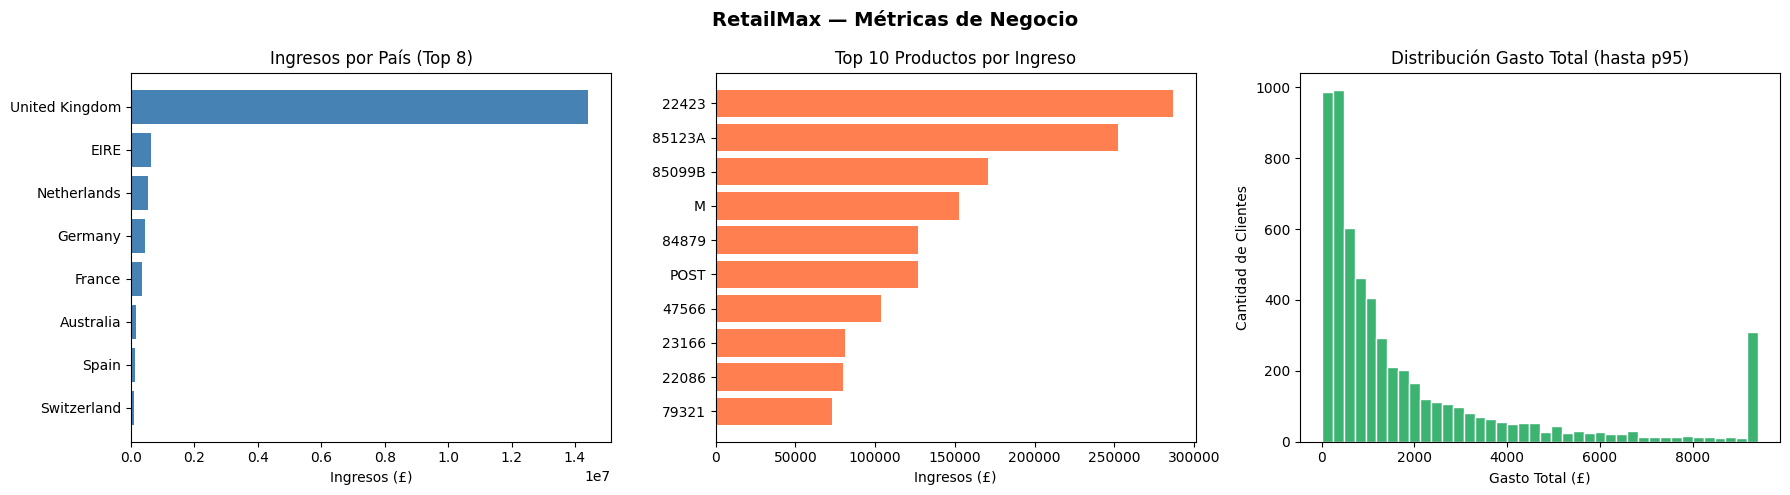

Visualización guardada: output/visualizaciones_l4.png


In [16]:
# ─── VISUALIZACIONES ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# Convertir a pandas para visualizar (colecciones pequeñas)
pd_paises    = df_ventas_pais.toPandas()
pd_productos = df_top_productos.toPandas()
pd_rfm       = df_rfm_labeled.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RetailMax — Métricas de Negocio', fontsize=14, fontweight='bold')

# Gráfico 1: Ingresos por país
axes[0].barh(pd_paises['country'][:8], pd_paises['ingresos_totales'][:8],
             color='steelblue')
axes[0].set_title('Ingresos por País (Top 8)')
axes[0].set_xlabel('Ingresos (£)')
axes[0].invert_yaxis()

# Gráfico 2: Top 10 productos por ingreso
axes[1].barh(pd_productos['stock_code'][:10], pd_productos['ingresos_totales'][:10],
             color='coral')
axes[1].set_title('Top 10 Productos por Ingreso')
axes[1].set_xlabel('Ingresos (£)')
axes[1].invert_yaxis()

# Gráfico 3: Distribución del gasto total (monetary) por cliente
axes[2].hist(pd_rfm['monetary'].clip(upper=pd_rfm['monetary'].quantile(0.95)),
             bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Distribución Gasto Total (hasta p95)')
axes[2].set_xlabel('Gasto Total (£)')
axes[2].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.savefig('output/visualizaciones_l4.png', bbox_inches='tight')
plt.show()
print('Visualización guardada: output/visualizaciones_l4.png')

# LECCIÓN 5 — Machine Learning Escalable: Spark MLlib
## Objetivo: Pipeline de Clasificación y Segmentación de Clientes

En esta lección construimos un pipeline completo de MLlib con dos modelos:
1. **Regresión Logística (supervisado):** clasificar si un cliente es VIP o no
2. **K-Means (no supervisado):** segmentar clientes en grupos de comportamiento

El input es el DataFrame RFM guardado en Parquet en la Lección 4.

In [17]:
# ─── CARGA DESDE PARQUET Y PREPARACIÓN ───────────────────────────────────────
from pyspark.ml.feature    import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering  import KMeans
from pyspark.ml.evaluation  import (BinaryClassificationEvaluator,
                                     MulticlassClassificationEvaluator)
from pyspark.ml             import Pipeline
from pyspark.sql            import functions as F

# Leer desde Parquet (simulamos inicio de sesión fresco como haría el equipo ML)
df_ml = spark.read.parquet('output/rfm_clientes.parquet')

# Asegurar tipos numéricos y eliminar nulos residuales
df_ml = (
    df_ml
    .select(
        F.col('customer_id'),
        F.col('recency').cast('double'),
        F.col('frequency').cast('double'),
        F.col('monetary').cast('double'),
        F.col('ticket_promedio').cast('double'),
        F.col('diversidad_productos').cast('double'),
        F.col('cliente_vip').cast('double').alias('label')
    )
    .dropna()
)

print(f'Registros para ML: {df_ml.count():,}')
df_ml.show(5)

Registros para ML: 5,875
+-----------+-------+---------+--------+---------------+--------------------+-----+
|customer_id|recency|frequency|monetary|ticket_promedio|diversidad_productos|label|
+-----------+-------+---------+--------+---------------+--------------------+-----+
|    13758.0|   11.0|     15.0| 9380.18|          30.65|               211.0|  1.0|
|    12533.0|  627.0|      2.0| 1328.29|          18.98|                61.0|  0.0|
|    14040.0|   40.0|     35.0|12620.52|          15.96|               332.0|  1.0|
|    17056.0|  738.0|      1.0|  124.85|          17.84|                 7.0|  0.0|
|    13526.0|  738.0|      2.0|  1182.0|          26.86|                29.0|  0.0|
+-----------+-------+---------+--------+---------------+--------------------+-----+
only showing top 5 rows



In [18]:
# ─── PIPELINE MLlib: REGRESIÓN LOGÍSTICA ─────────────────────────────────────
# Etapas del pipeline:
# 1. VectorAssembler → une features en un vector
# 2. StandardScaler  → normaliza (media=0, std=1) para LR
# 3. LogisticRegression → modelo de clasificación binaria

FEATURE_COLS = ['recency', 'frequency', 'monetary', 'ticket_promedio', 'diversidad_productos']

assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol='features_raw'
)

scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True,
    withStd=True
)

lr = LogisticRegression(
    featuresCol='features',
    labelCol='label',
    maxIter=50,
    regParam=0.01,       # Regularización L2
    elasticNetParam=0.0  # Ridge puro
)

pipeline_lr = Pipeline(stages=[assembler, scaler, lr])

# División train/test
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
print(f'Train: {train_df.count():,} | Test: {test_df.count():,}')

# Entrenar
model_lr = pipeline_lr.fit(train_df)
print('Modelo de Regresión Logística entrenado.')

Train: 4,750 | Test: 1,125
Modelo de Regresión Logística entrenado.


In [19]:
# ─── EVALUACIÓN: REGRESIÓN LOGÍSTICA ─────────────────────────────────────────

pred_lr = model_lr.transform(test_df)

# AUC-ROC
eval_binary = BinaryClassificationEvaluator(
    labelCol='label', metricName='areaUnderROC'
)
auc = eval_binary.evaluate(pred_lr)

# Accuracy
eval_multi = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy'
)
acc = eval_multi.evaluate(pred_lr)

# F1-Score
eval_f1 = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='f1'
)
f1 = eval_f1.evaluate(pred_lr)

print('=== MÉTRICAS — Regresión Logística (Clasificación Cliente VIP) ===')
print(f'  AUC-ROC  : {auc:.4f}')
print(f'  Accuracy : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  F1-Score : {f1:.4f}')

# Coeficientes del modelo
lr_model = model_lr.stages[-1]
coefs = dict(zip(FEATURE_COLS, lr_model.coefficients.toArray()))
print('\nCoeficientes del modelo:')
for feat, coef in sorted(coefs.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {feat:25s}: {coef:+.4f}')

# Mostrar algunas predicciones
pred_lr.select('customer_id', 'label', 'prediction', 'probability').show(8)

=== MÉTRICAS — Regresión Logística (Clasificación Cliente VIP) ===
  AUC-ROC  : 0.9747
  Accuracy : 0.9084  (90.8%)
  F1-Score : 0.9031

Coeficientes del modelo:
  frequency                : +2.0594
  monetary                 : +1.6014
  diversidad_productos     : +1.1297
  ticket_promedio          : +0.7015
  recency                  : -0.4758
+-----------+-----+----------+--------------------+
|customer_id|label|prediction|         probability|
+-----------+-----+----------+--------------------+
|    12348.0|  0.0|       0.0|[0.85439291055013...|
|    12352.0|  1.0|       0.0|[0.60694860254036...|
|    12354.0|  0.0|       0.0|[0.92856404346777...|
|    12359.0|  1.0|       1.0|[0.09422876597487...|
|    12365.0|  0.0|       0.0|[0.94855609039766...|
|    12369.0|  0.0|       0.0|[0.91235117471398...|
|    12375.0|  0.0|       0.0|[0.91516426372655...|
|    12381.0|  0.0|       0.0|[0.77769732423251...|
+-----------+-----+----------+--------------------+
only showing top 8 rows



In [20]:
# ─── PIPELINE MLlib: K-MEANS (SEGMENTACIÓN NO SUPERVISADA) ───────────────────
# K-Means agrupa clientes en K segmentos basados en sus métricas RFM.
# No usamos la etiqueta 'label'; es puramente no supervisado.

assembler_km = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol='features_raw'
)

scaler_km = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True, withStd=True
)

kmeans = KMeans(
    featuresCol='features',
    predictionCol='segmento',
    k=4,           # 4 segmentos de clientes (hiper-parámetro de negocio)
    seed=42,
    maxIter=20
)

pipeline_km = Pipeline(stages=[assembler_km, scaler_km, kmeans])

# Entrenar sobre el dataset completo (sin dividir: no supervisado)
model_km = pipeline_km.fit(df_ml)
print('Modelo K-Means entrenado.')

# WSSSE: Within Set Sum of Squared Errors (inercia)
df_segmentado = model_km.transform(df_ml)
kmeans_model = model_km.stages[-1]
wssse = kmeans_model.summary.trainingCost
print(f'WSSSE (inercia): {wssse:,.2f}')

Modelo K-Means entrenado.
WSSSE (inercia): 14,278.30


In [21]:
# ─── ANÁLISIS DE SEGMENTOS K-MEANS ───────────────────────────────────────────

print('=== PERFIL DE SEGMENTOS DE CLIENTES ===')
df_perfil = (
    df_segmentado
    .groupBy('segmento')
    .agg(
        F.count('customer_id').alias('n_clientes'),
        F.round(F.avg('recency'), 1).alias('recency_prom'),
        F.round(F.avg('frequency'), 1).alias('frequency_prom'),
        F.round(F.avg('monetary'), 2).alias('monetary_prom'),
        F.round(F.avg('ticket_promedio'), 2).alias('ticket_prom'),
        F.round(F.avg('diversidad_productos'), 1).alias('diversidad_prom')
    )
    .orderBy('monetary_prom', ascending=False)
)
df_perfil.show(truncate=False)

# Etiquetas interpretativas de negocio (basadas en el perfil RFM)
pd_perfil = df_perfil.toPandas().sort_values('monetary_prom', ascending=False)
etiquetas_negocio = ['Champions 🏆', 'Leales 💚', 'En Riesgo ⚠️', 'Hibernando ❄️']
pd_perfil['etiqueta'] = etiquetas_negocio[:len(pd_perfil)]
print('\nEtiquetas de segmento sugeridas para marketing:')
print(pd_perfil[['segmento', 'etiqueta', 'n_clientes', 'monetary_prom', 'recency_prom']].to_string(index=False))

=== PERFIL DE SEGMENTOS DE CLIENTES ===
+--------+----------+------------+--------------+-------------+-----------+---------------+
|segmento|n_clientes|recency_prom|frequency_prom|monetary_prom|ticket_prom|diversidad_prom|
+--------+----------+------------+--------------+-------------+-----------+---------------+
|2       |9         |1.9         |216.7         |252590.63    |113.37     |1348.8         |
|3       |540       |33.0        |25.0          |13677.94     |28.34      |307.8          |
|0       |3371      |74.4        |5.1           |1833.86      |30.44      |68.8           |
|1       |1955      |466.2       |2.1           |800.64       |55.61      |33.2           |
+--------+----------+------------+--------------+-------------+-----------+---------------+


Etiquetas de segmento sugeridas para marketing:
 segmento      etiqueta  n_clientes  monetary_prom  recency_prom
        2   Champions 🏆           9      252590.63           1.9
        3      Leales 💚         540       13

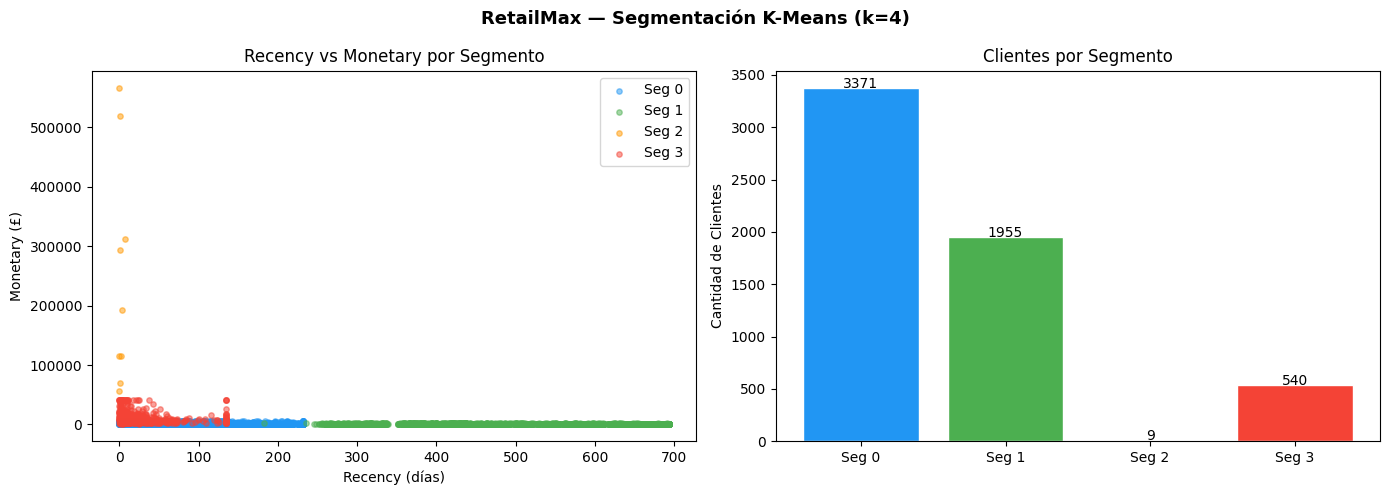

Visualización guardada: output/segmentacion_kmeans.png


In [22]:
# ─── VISUALIZACIÓN DE SEGMENTOS ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

pd_seg = df_segmentado.select('recency', 'frequency', 'monetary', 'segmento').toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RetailMax — Segmentación K-Means (k=4)', fontsize=13, fontweight='bold')

colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
for seg_id in sorted(pd_seg['segmento'].unique()):
    subset = pd_seg[pd_seg['segmento'] == seg_id]
    axes[0].scatter(
        subset['recency'].clip(upper=subset['recency'].quantile(0.95)),
        subset['monetary'].clip(upper=subset['monetary'].quantile(0.95)),
        c=colores[seg_id], alpha=0.5, label=f'Seg {seg_id}', s=15
    )

axes[0].set_xlabel('Recency (días)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Recency vs Monetary por Segmento')
axes[0].legend()

# Barras: tamaño de cada segmento
conteo = pd_seg['segmento'].value_counts().sort_index()
axes[1].bar([f'Seg {i}' for i in conteo.index], conteo.values,
            color=colores[:len(conteo)], edgecolor='white')
axes[1].set_title('Clientes por Segmento')
axes[1].set_ylabel('Cantidad de Clientes')
for i, v in enumerate(conteo.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('output/segmentacion_kmeans.png', bbox_inches='tight')
plt.show()
print('Visualización guardada: output/segmentacion_kmeans.png')

In [24]:
# ─── GUARDAR RESULTADOS FINALES ───────────────────────────────────────────────
import os
os.makedirs('output', exist_ok=True)

# Predicciones LR → CSV
(
    pred_lr.select('customer_id', 'label', 'prediction')
    .toPandas()
    .to_csv('output/predicciones_lr.csv', index=False)
)

# Segmentación K-Means → CSV
(
    df_segmentado.select('customer_id', 'recency', 'frequency',
                          'monetary', 'ticket_promedio', 'segmento')
    .toPandas()
    .to_csv('output/segmentos_kmeans.csv', index=False)
)

print('Archivos de salida generados:')
for f in ['output/predicciones_lr.csv', 'output/segmentos_kmeans.csv',
          'output/visualizaciones_l4.png', 'output/segmentacion_kmeans.png']:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f'  ✓ {f} ({size:,} bytes)')

Archivos de salida generados:
  ✓ output/predicciones_lr.csv (18,029 bytes)
  ✓ output/segmentos_kmeans.csv (191,262 bytes)
  ✓ output/visualizaciones_l4.png (63,327 bytes)
  ✓ output/segmentacion_kmeans.png (58,458 bytes)


In [26]:
# ─── CIERRE DE SESIÓN SPARK ───────────────────────────────────────────────────
spark.stop()
print('SparkSession cerrada correctamente.')

SparkSession cerrada correctamente.
